# Decision Tree Volume Model

This notebook contains the decision tree model that we'll use to predict trade volume on high frequent BTC-USDT minute data.


## Imports and Basic Data Loading

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor


## Exchange Selection
We now have separate feature parquet files per exchange. Set the exchange here and the notebook will use the correct dataset.


In [15]:
# choose the exchange we want to use
DATA_DIR = Path("features_by_exchange")
feature_paths = sorted(DATA_DIR.glob("BTC-USDT_features_*_15min.parquet"))
available_exchanges = [
    p.name.replace("BTC-USDT_features_", "").replace("_15min.parquet", "")
    for p in feature_paths
]

EXCHANGE = "BINANCE"  # change this as needed

if EXCHANGE not in available_exchanges:
    raise ValueError(f"Exchange {EXCHANGE} not found. Available: {available_exchanges}")

feature_path = DATA_DIR / f"BTC-USDT_features_{EXCHANGE}_15min.parquet"
print("Using:", feature_path)


Using: features_by_exchange/BTC-USDT_features_BINANCE_15min.parquet


In [16]:
# read parquet from repository, and then get some basic information
_df = pd.read_parquet(feature_path)
_df.head()


,volume,num_trades,avg_trade_size,median_trade_size,trade_notional,buy_volume,sell_volume,buy_notional,sell_notional,open_price,...,rolling_volume_std,cumulative_volume,time_of_day,trade_rate_sec,trade_imbalance,return,abs_return,realized_volatility,price_range,momentum
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-05-01 00:00:00,120.12412,29398,0.004086,0.00006,1.132344e+07,68.42689,0.0,6.450149e+06,0.0,94172.00,...,0.0,120.12412,0,32.664444,1.0,0.000000,0.000000,0.001177,217.40,0.000000
2025-05-01 00:15:00,68.80927,21553,0.003193,0.00006,6.485163e+06,36.22009,0.0,3.413184e+06,0.0,94269.03,...,0.0,188.93339,15,23.947778,1.0,0.000224,0.000224,0.000816,146.55,0.000000
2025-05-01 00:30:00,46.15750,17365,0.002658,0.00006,4.350832e+06,16.03284,0.0,1.511336e+06,0.0,94290.16,...,0.0,235.09089,30,19.294444,1.0,0.000045,0.000045,0.000785,82.61,0.000000
2025-05-01 00:45:00,85.96306,12189,0.007053,0.00006,8.112038e+06,43.18460,0.0,4.075107e+06,0.0,94316.27,...,0.0,321.05395,45,13.543333,1.0,0.001178,0.001178,0.000790,89.21,0.000000
2025-05-01 01:00:00,109.86491,21365,0.005142,0.00006,1.038418e+07,63.53577,0.0,6.004894e+06,0.0,94405.46,...,0.0,430.91886,60,23.738889,1.0,0.001346,0.001346,0.000974,201.48,0.002795


In [17]:
# lots of columns, so we just get some more information
print(_df.shape)


(2976, 29)


In [18]:
# tells us the time window
print(_df.index.min(), _df.index.max())


2025-05-01 00:00:00 2025-05-31 23:45:00


In [19]:
# gives us the columns of the first 15. Clearly volume is our target.
print(_df.columns.tolist()[:15])


['volume', 'num_trades', 'avg_trade_size', 'median_trade_size', 'trade_notional', 'buy_volume', 'sell_volume', 'buy_notional', 'sell_notional', 'open_price', 'high_price', 'low_price', 'close_price', 'lag_volume_1', 'lag_volume_2']


## Training/Testing Split and Relevant Features

Obviously we're trying to preidct volume using other numeric features, and then split by time for out of sample testing as well. We'll cross validate in a time-series orientation, and then use gridsearch to tune maximum depth and the minimum samples leaf parameter.

Steps:
1. get numerical columns only for the model (should be around all other features)
2. separate target from labels and then split 80:20
3. Have a naive baseline
4. Train and Tune the Model
5. Get the maximum depth and the minimum sample leaf as well


In [20]:
# every single value that's a number is copied. np.number gives all scalar numeric types
_df = _df.select_dtypes(include=[np.number]).copy()

# We want to forecast next-minute volume, so shift features by 1 and target by -1
# This avoids leakage from same-minute values like buy/sell volume or cumulative volume.
X = _df.drop(columns=["volume"]).shift(1)
y = _df["volume"].shift(-1)

# Baseline prediction: use current volume to predict next minute
baseline_series = _df["volume"].shift(1)

# Clean infinities
X = X.replace([np.inf, -np.inf], np.nan)

# Align and drop any rows with NaNs in X, y, or baseline
valid_mask = X.notna().all(axis=1) & y.notna() & baseline_series.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]
baseline_series = baseline_series.loc[valid_mask]

# Time-based split (we'll make the last 20% as test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
baseline_test = baseline_series.iloc[split_idx:]

# what does the shape look like?
print(X_train.shape, X_test.shape)


(2379, 28) (595, 28)


## Extra Data Visualizations
We add a few more graphs to understand the data distribution and time behavior.


In [21]:
# set a time index for plots
if isinstance(_df.index, pd.DatetimeIndex):
    time_index = _df.index
elif "timestamp" in _df.columns:
    time_index = pd.to_datetime(_df["timestamp"])
else:
    time_index = pd.RangeIndex(len(_df))

# sample for visualization speed
sample_n = min(5000, len(_df))
plot_df = _df.iloc[:sample_n].copy()
plot_time = time_index[:sample_n]


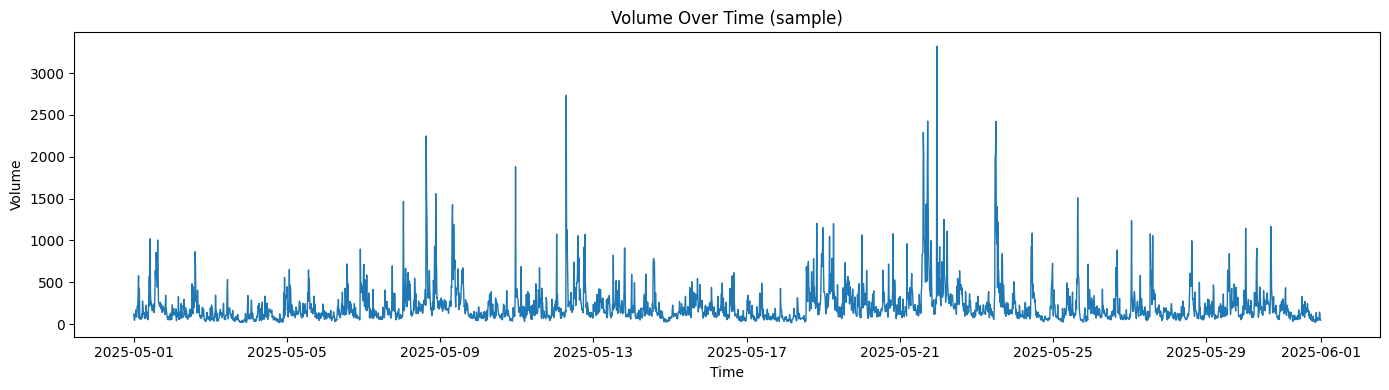

In [22]:
# Volume over time
plt.figure(figsize=(14, 4))
plt.plot(plot_time, plot_df["volume"], linewidth=1)
plt.title("Volume Over Time (sample)")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()


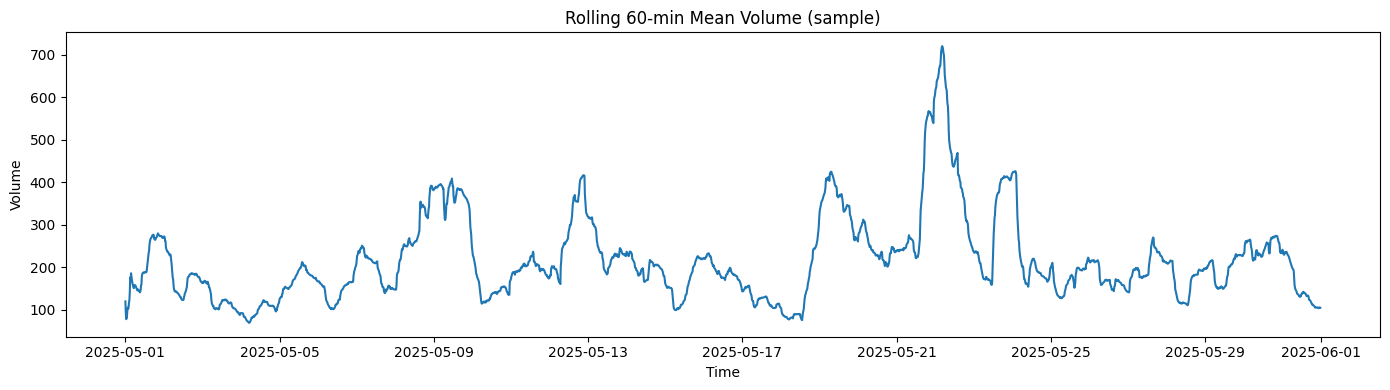

In [23]:
# Rolling mean of volume
rolling = plot_df["volume"].rolling(60, min_periods=1).mean()
plt.figure(figsize=(14, 4))
plt.plot(plot_time, rolling, linewidth=1.5)
plt.title("Rolling 60-min Mean Volume (sample)")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.tight_layout()
plt.show()


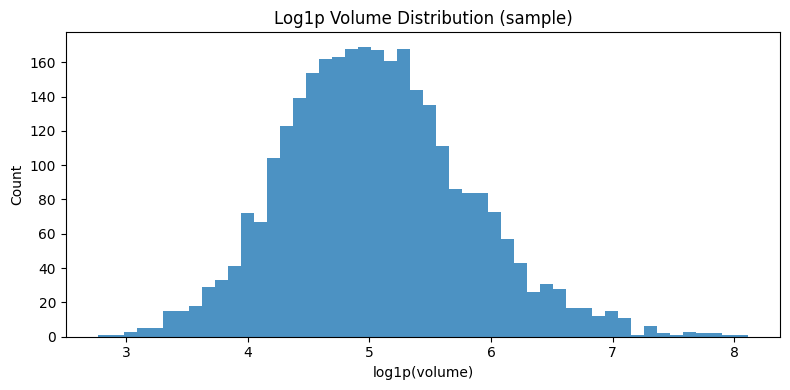

In [24]:
# Volume distribution (log1p)
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(plot_df["volume"]), bins=50, alpha=0.8)
plt.title("Log1p Volume Distribution (sample)")
plt.xlabel("log1p(volume)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Evaluation

Basic metrics that I'll use:
- Mean Absolute Error
- RMSE
- $R^2$


In [25]:
# Baseline: predict next-minute volume with the current minute's volume
pred = baseline_test.copy()


In [26]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"mae: {mae}")
print(f"rmse: {rmse}")
print(f"r2: {r2}")


mae: 108.51284218487395
rmse: 188.50226703432847
r2: -0.3389582927182293


## Train and Tune the Model

In [27]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 10],
}

dt = DecisionTreeRegressor(random_state=42)

grid = GridSearchCV(
    dt,
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

grid.fit(X_train, y_train)
print(grid.best_params_)

best_dt = grid.best_estimator_

dt_pred = best_dt.predict(X_test)


{'max_depth': 3, 'min_samples_leaf': 10}


In [28]:
def evaluate_predictions(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }

metrics = evaluate_predictions(y_test, dt_pred)
print(metrics)


{'mae': 104.32246970700699, 'rmse': np.float64(164.24836618552374), 'r2': -0.01656700724540472}


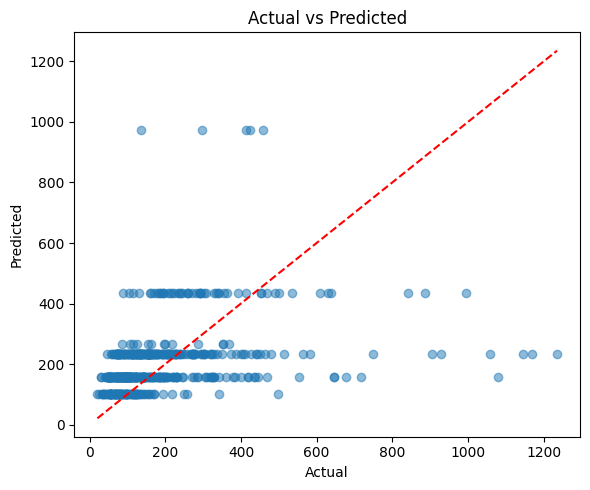

In [29]:
# Diagnostics: actual vs predicted
plt.figure(figsize=(6, 5))
plt.scatter(y_test, dt_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


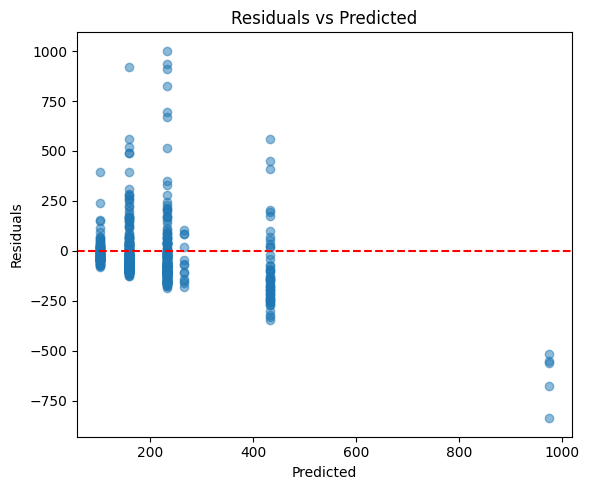

In [30]:
# Diagnostics: residuals vs predicted
residuals = y_test - dt_pred
plt.figure(figsize=(6, 5))
plt.scatter(dt_pred, residuals, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


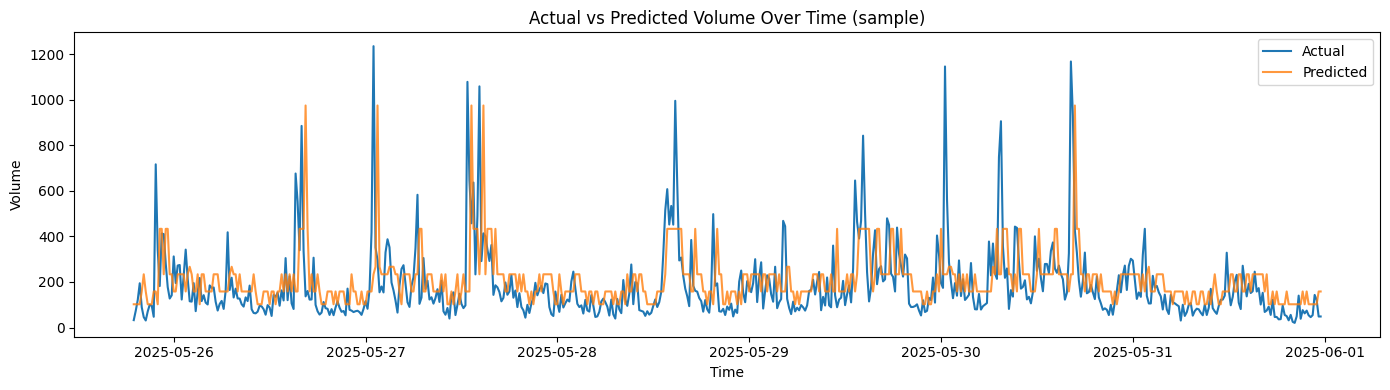

In [31]:
# Predicted vs actual over time (sample)
plot_n = min(3000, len(y_test))
plt.figure(figsize=(14, 4))
plt.plot(y_test.index[:plot_n], y_test.iloc[:plot_n], label="Actual", linewidth=1.5)
plt.plot(y_test.index[:plot_n], dt_pred[:plot_n], label="Predicted", linewidth=1.5, alpha=0.8)
plt.title("Actual vs Predicted Volume Over Time (sample)")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.show()


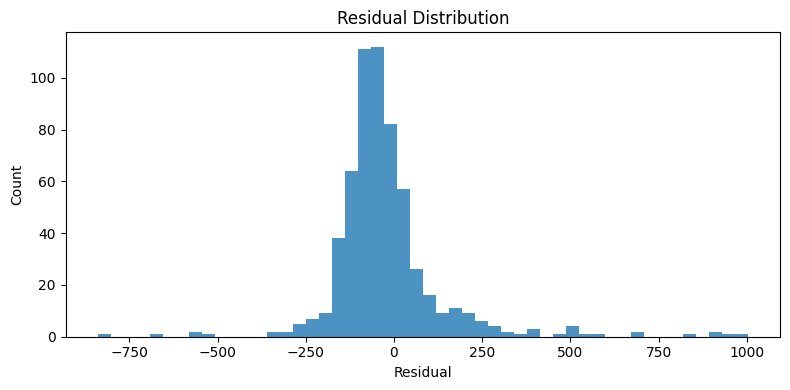

In [32]:
# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, alpha=0.8)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [33]:
# Feature importances
importances = pd.Series(best_dt.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(15))


trade_notional         0.730717
buy_notional           0.130651
median_trade_size      0.078195
cumulative_volume      0.060437
num_trades             0.000000
prev_day_volume        0.000000
price_range            0.000000
realized_volatility    0.000000
abs_return             0.000000
return                 0.000000
trade_imbalance        0.000000
trade_rate_sec         0.000000
time_of_day            0.000000
rolling_volume_std     0.000000
rolling_volume_mean    0.000000
dtype: float64


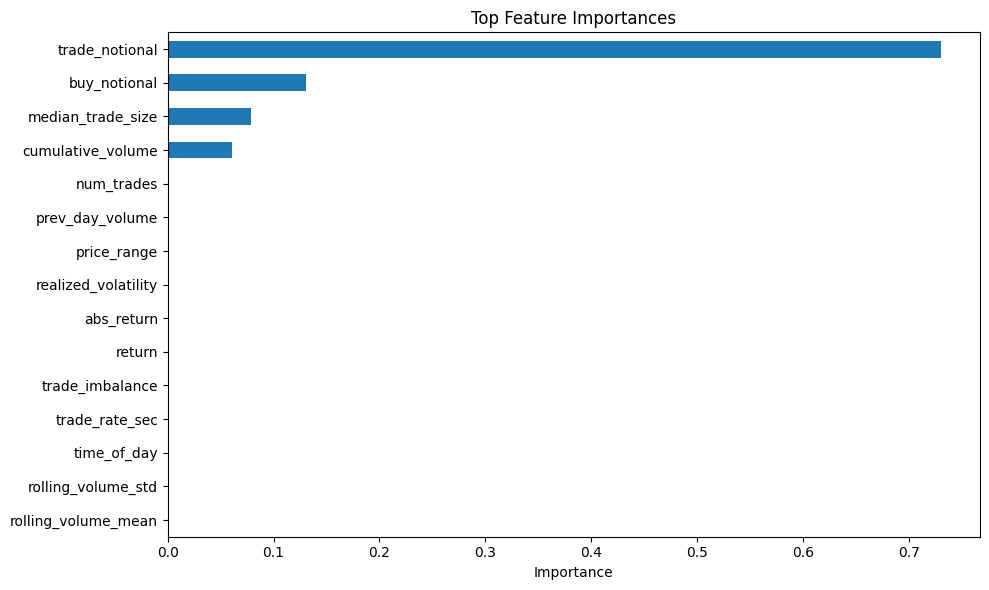

In [34]:
plt.figure(figsize=(10, 6))
importances.head(15).iloc[::-1].plot(kind="barh")
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
